# Pretrain A/B/C **품질** 비교 (RMSE + 슬롯 분포 검증)

`compare_pretrain_ab.py` 노트북은 *속도/리소스* 만 비교합니다. 이 노트북은 그 자매편으로 **모델 정확도** (downstream RMSE) 를 비교하고, 동시에 "진짜로 augmentation 이 weighted 로 바뀌었는지" 를 슬롯 빈도 분포로 검증합니다.

비교 대상 (전부 ESOL 동일 시드/하이퍼파라미터, augmentation 정책만 다름):

| 측면 | aug_1 / aug_2 | views_fn | 슬롯 |
|---|---|---|---|
| **A** baseline | `MMFFrandom` / `MMFFrandom` | `RandomView` (원본 PyG 경로) | 사전 추출된 2개 균등 |
| **B** top1+identity | `MMFFweighted_top1` / `None` | view1=`WeightedMMFFView`(top1), view2=identity | QDF 가중치로 argmax 슬롯; 두 번째 뷰는 원본 `pos` |
| **C** weighted pair | `SIDE_C_AUG_2` (예: `top12`) | `WeightedMMFFView` 등 | **MMFF1..4** + `.pt` 가중치; C는 1등 vs 2등 슬롯 등 페어 설정 가능 |

각 셀은 독립적으로 다시 돌릴 수 있으며, 셀 1 의 `QUALITY_SMOKE`·`P_EPOCH`·`F_EPOCH`·`BATCH_SIZE` 등으로 빠른 스모크 ↔ 본격 실험을 오갑니다.

프리트레인 체크포인트는 각 측면별 **별도 폴더** (`./models/quality_<ts>/A`, `B`, `C`) 에 저장됩니다. PNG / JSON 은 `figs/pretrain_quality_<MMDD_HHMM>/` 에 들어갑니다.

In [1]:
# --- 1. Setup ---------------------------------------------------------------
import os, sys, json, time, gc
from datetime import datetime
from pathlib import Path

NB_DIR = Path.cwd()
# 노트북 launcher 의 CWD 가 어디든 repo root 로 정렬.
REPO_ROOT = NB_DIR
for _p in [NB_DIR, *NB_DIR.parents]:
    if (_p / 'dig').is_dir() and (_p / 'examples').is_dir():
        REPO_ROOT = _p
        break
os.chdir(REPO_ROOT)
for p in [REPO_ROOT, REPO_ROOT / 'examples' / 'sslgraph' / 'bench']:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import numpy as np
import matplotlib.pyplot as plt
import torch
from dig.sslgraph.utils.device import pick_torch_device
import pretrain_quality_core as q

FIG_TS = datetime.now().strftime('%m%d_%H%M')
RUN_DIR = REPO_ROOT / 'examples' / 'sslgraph' / 'bench' / 'figs' / f'pretrain_quality_{FIG_TS}'
RUN_DIR.mkdir(parents=True, exist_ok=True)
MODEL_ROOT = REPO_ROOT / 'models' / f'quality_{FIG_TS}'
MODEL_ROOT.mkdir(parents=True, exist_ok=True)

DEVICE = pick_torch_device()
print('device:', DEVICE)
print('run dir:', RUN_DIR)
print('models  :', MODEL_ROOT)

# ===== 사용자가 자주 만지는 노브 =================================================
DATASET        = 'esol'      # pretrain + finetune 공통
BATCH_SIZE     = 400
P_EPOCH        = 50          # 본격 비교. 스모크는 아래 QUALITY_SMOKE 블록에서 덮어씀.
F_EPOCH        = 100         # 본격 finetune 기본값(스모크에서 18로 축소).
FINETUNE_BATCH = 128         # finetune.ipynb 기본 32 → 128 (XPU 점유율 ↑, ~2-3× 빠름)
N_TIMES        = 3           # 본격 비교에서 분산 줄이려면 ≥3.
N_FOLDS        = 5           # 본격 비교(5-fold). 스모크에서 2로 축소.
WEIGHT_KT     = 0.3       # softmax 온도. homolumo 는 rotamer 간 차이가 작아 0.3 권장(atomization 0.5).
WEIGHT_MODE   = 'auto'    # 'explicit' / 'energy' / 'auto'
WEIGHT_NORM   = 'zscore'  # 'none' / 'zscore' / 'rank'. QDF 출력 차이가 작으므로 zscore 권장.
WEIGHT_SOURCE = 'qdf'     # 'qdf' (CSV 기반) or 'boltzmann' (에너지 기반)
QDF_PROPERTY  = 'homolumo'     # 'homolumo'    (QM9under7atoms dim=200 op=mean, ESOL은 OOD라 zscore 필수)
                               # 'atomization' (대안: QM9under14atoms dim=250 op=sum, conformer 민감)
QDF_CHECKPOINT = None     # None = qdf_mmff_predict.py 의 preset 사용
                          # 다른 ckpt 시도 시 절대/상대 경로 입력
SCORE_EXPR    = None      # None = property 의 default
                          #   atomization → 'energy'  (높을수록 안정)
                          #   homolumo    → '-(lumo - homo)' (gap 클수록 안정)
WEIGHT_FALLBACK = 'boltzmann'  # QDF가 cover 못한 분자 처리. 'boltzmann' 권장.
                               # 'boltzmann' = MMFF 에너지 기반 Boltzmann (커버리지 100%)
                               # 'uniform'   = 0.25 균등 (= side A 와 동일)
                               # 'skip'      = .pt 에 빠뜨림 → view 가 균등 fallback
QDF_PRED_CSV = REPO_ROOT / 'dataset' / f'esol_qdf_mmff_preds_{QDF_PROPERTY}.csv'
WEIGHTS_PT   = REPO_ROOT / 'dataset' / f'esol_mmff_weights_qdf_{QDF_PROPERTY}.pt'
DIST_N_CALLS = 50         # 슬롯 분포 검증용 view 호출 횟수
DIST_BATCH   = 256

SIDES = ('A', 'B', 'C')
QUALITY_SMOKE = False   # True: 짧은 epoch/fold + SchNet (테스트용). False: 아래 본값 사용.
colors = {'A': '#7f7f7f', 'B': '#2ca02c', 'C': '#d62728'}
labels = {
    'A': 'A baseline (RandomView)',
    'B': 'B top1 + identity',
    'C': 'C weighted (top1 vs top2)',
}

# --- epoch wall-time (DataLoader + mixed-precision forward) -----------------
# ESOL 은 epoch 당 배치 수가 적어서(≈3 @400) GPU/XPU 커널이 병목인 경우가 많습니다.
PRETRAIN_NUM_WORKERS = 0   # Linux/WSL: 4~8 권장. Windows+RDKit 에서 worker 오류 시 0 유지.
PRETRAIN_PIN_MEMORY = True # 호스트→디바이스 복사 힌트; 문제 시 False.
PRETRAIN_AMP = True        # CUDA/XPU 에서 encoder+proj forward autocast (미지원 시 자동 무시).

# --- 진단 순서 (A → C → B): cutoff, side-C view-2, 백본 --------------------
# (A) SchNet cutoff 축소: 국소 RBF가 conformers 차이에 더 민감해지도록.
PRETRAIN_CUTOFF = 3.0
# (C) Side C 의 view 페어 선택 방식.
#   "top1"         — 양쪽 view 모두 1등(argmax) 슬롯만. 2등은 계산도 안 함.
#                    positive pair = 같은 좌표 두 번. augmentation=identity
#                    ablation.
#   "top12"        — (1등, 2등) 결정적 짝. 두 view 가 같은 그래프에서 항상
#                    가장 가중치 높은 / 두 번째 슬롯을 가져옵니다.
#   "noise"        — view1=MMFFweighted, view2=NodeTranslation(noise) (약함)
#   "MMFFweighted" — 레거시(양쪽 모두 가중 i.i.d. 샘플)
SIDE_C_AUG_2 = "top12"   # Side C: 1등 vs 2등 슬롯 (결정적). 스모크/본실험 공통 권장.
# pretrain 백본; finetune 은 summary 의 pretrain_encoder / cutoff 를 따름.
PRETRAIN_ENCODER = "spherenet"  # 본실험: angle/torsion. QUALITY_SMOKE 시 아래에서 schnet 으로 덮어씀.

if QUALITY_SMOKE:
    # 목표: XPU 기준 총 ~5분.
    #   pretrain  : 5 ep × 3 sides ≈ 1분
    #   slot dist : 20 calls × 3 sides ≈ 30s
    #   finetune  : 18 ep × 2 fold × 3 sides × 2.6s ≈ 4.5분
    P_EPOCH, F_EPOCH = 5, 18
    N_FOLDS, N_TIMES = 2, 1
    DIST_N_CALLS, DIST_BATCH = 20, 128
    PRETRAIN_ENCODER = "schnet"

os.environ['DATALOADER_NUM_WORKERS'] = str(int(PRETRAIN_NUM_WORKERS))
if PRETRAIN_PIN_MEMORY:
    os.environ['PIN_MEMORY'] = '1'
else:
    os.environ.pop('PIN_MEMORY', None)
# ============================================================================

print({
    'DATASET': DATASET, 'BATCH_SIZE': BATCH_SIZE,
    'SIDES': SIDES, 'QUALITY_SMOKE': QUALITY_SMOKE,
    'P_EPOCH': P_EPOCH, 'F_EPOCH': F_EPOCH,
    'N_TIMES': N_TIMES, 'N_FOLDS': N_FOLDS,
    'WEIGHT_KT': WEIGHT_KT, 'WEIGHT_MODE': WEIGHT_MODE,
    'WEIGHT_NORM': WEIGHT_NORM, 'WEIGHT_SOURCE': WEIGHT_SOURCE,
    'QDF_PROPERTY': QDF_PROPERTY, 'QDF_PRED_CSV': QDF_PRED_CSV.name,
    'WEIGHTS_PT': WEIGHTS_PT.name,
    'DIST_N_CALLS': DIST_N_CALLS, 'DIST_BATCH': DIST_BATCH,
    'PRETRAIN_NUM_WORKERS': PRETRAIN_NUM_WORKERS,
    'PRETRAIN_PIN_MEMORY': PRETRAIN_PIN_MEMORY,
    'PRETRAIN_AMP': PRETRAIN_AMP,
    'PRETRAIN_CUTOFF': PRETRAIN_CUTOFF,
    'SIDE_C_AUG_2': SIDE_C_AUG_2,
    'PRETRAIN_ENCODER': PRETRAIN_ENCODER,
})

device: xpu:0
run dir: c:\DGCL\3DGCL\examples\sslgraph\bench\figs\pretrain_quality_0513_1425
models  : c:\DGCL\3DGCL\models\quality_0513_1425
{'DATASET': 'esol', 'BATCH_SIZE': 400, 'SIDES': ('A', 'B', 'C'), 'QUALITY_SMOKE': False, 'P_EPOCH': 25, 'F_EPOCH': 25, 'N_TIMES': 1, 'N_FOLDS': 1, 'WEIGHT_KT': 0.5, 'WEIGHT_MODE': 'auto', 'WEIGHT_NORM': 'zscore', 'WEIGHT_SOURCE': 'qdf', 'QDF_PROPERTY': 'atomization', 'QDF_PRED_CSV': 'esol_qdf_mmff_preds_atomization.csv', 'WEIGHTS_PT': 'esol_mmff_weights_qdf_atomization.pt', 'DIST_N_CALLS': 50, 'DIST_BATCH': 256, 'PRETRAIN_NUM_WORKERS': 0, 'PRETRAIN_PIN_MEMORY': True, 'PRETRAIN_AMP': True, 'PRETRAIN_CUTOFF': 3.0, 'SIDE_C_AUG_2': 'top12', 'PRETRAIN_ENCODER': 'spherenet'}


## 1. weights 파일 준비

**B 또는 C** 측면을 돌리려면 `MMFF_WEIGHTS_PATH` (per-graph slot weights `.pt`) 가 필요합니다.

| `WEIGHT_SOURCE` | `QDF_PROPERTY` | CSV columns | 의미 | 권장 사용처 |
|---|---|---|---|---|
| `qdf` | `atomization` | `smiles,slot,energy` | softmax(z-score(energy)/kT) — **conformer 별로 큰 차이**, ESOL/큰 분자에 강함 | **현재 기본값** |
| `qdf` | `homolumo` | `smiles,slot,homo,lumo` | softmax(z-score(-(LUMO-HOMO))/kT) — QM9 ground-state 에서만 좋고 MMFF rotamer 차이는 ~1 meV | 비교/회귀 분석용 |
| `boltzmann` | — | (CSV 없이 MMFF energy) | softmax(-(E_k - E_min)/kT) | QDF 모델이 사용 불가일 때 |

체크포인트 선택은 `qdf_mmff_predict.py` 가 `--qdf-property` 의 **preset** 으로 자동 결정합니다.
다른 ckpt 를 시도하려면 setup 셀의 `QDF_CHECKPOINT` 에 경로를 넣으세요.

| `QDF_PROPERTY` | preset checkpoint |
|---|---|
| `atomization` | `output/model--QM9under14atoms_atomizationenergy_eV--6-31G--…--dim250--hidden_HK250--sum--batch_size4--iteration2000` |
| `homolumo`    | `output/model--QM9under7atoms_homolumo_eV--6-31G--…--dim200--hidden_HK200--mean--batch_size8--iteration2000` |

이미 `dataset/esol_mmff_weights_qdf_<property>.pt` 가 있으면 캐시를 씁니다. 다만 **디스크에 저장된 `kT` 가 셀 1 의 `WEIGHT_KT` 와 다르면** (가중치 첨예화 변경 시) 자동으로 `compute_mmff_weights.py` 를 다시 돌려 `.pt` 를 갱신합니다.

In [2]:
# --- 2. Ensure weights .pt --------------------------------------------------
import subprocess

PY = sys.executable

def _run(cmd, **kw):
    print('$', ' '.join(str(c) for c in cmd))
    return subprocess.run([str(c) for c in cmd], check=True, **kw)

_rebuild_weights = not WEIGHTS_PT.is_file()
if WEIGHTS_PT.is_file():
    _w0 = torch.load(WEIGHTS_PT, map_location='cpu', weights_only=False)
    _disk_kt = float(_w0.get('kT', float('nan')))
    _disk_fb = _w0.get('fallback')
    _disk_fb_policy = _disk_fb.get('policy') if isinstance(_disk_fb, dict) else None
    if abs(_disk_kt - float(WEIGHT_KT)) > 1e-6:
        print('[info] on-disk kT', _disk_kt, '!= WEIGHT_KT', WEIGHT_KT,
              '— recomputing .pt so softmax temperature (D) matches setup.')
        _rebuild_weights = True
    elif WEIGHT_SOURCE == 'qdf' and _disk_fb_policy != WEIGHT_FALLBACK:
        print('[info] on-disk fallback', _disk_fb_policy, '!= WEIGHT_FALLBACK',
              WEIGHT_FALLBACK, '— recomputing so QDF-uncovered molecules use the new policy.')
        _rebuild_weights = True

if _rebuild_weights:
    if WEIGHT_SOURCE == 'qdf':
        if not QDF_PRED_CSV.is_file():
            print(f'[info] running qdf_mmff_predict.py ({QDF_PROPERTY}) — this is slow.')
            pred_cmd = [PY, 'examples/sslgraph/bench/qdf_mmff_predict.py',
                        '--dataset', DATASET,
                        '--qdf-property', QDF_PROPERTY,
                        '--out', QDF_PRED_CSV]
            if QDF_CHECKPOINT:
                pred_cmd += ['--checkpoint', str(QDF_CHECKPOINT)]
            _run(pred_cmd)
        weights_cmd = [PY, 'examples/sslgraph/bench/compute_mmff_weights.py',
                       '--dataset', DATASET, '--source', 'qdf',
                       '--pred-csv', QDF_PRED_CSV,
                       '--kT', WEIGHT_KT,
                       '--normalize', WEIGHT_NORM,
                       '--fallback', WEIGHT_FALLBACK,
                       '--out', WEIGHTS_PT]
        if SCORE_EXPR:
            weights_cmd += ['--score-expr', SCORE_EXPR]
        _run(weights_cmd)
    else:
        _run([PY, 'examples/sslgraph/bench/compute_mmff_weights.py',
              '--dataset', DATASET, '--source', 'boltzmann',
              '--kT', WEIGHT_KT,
              '--out', WEIGHTS_PT])

print('weights file:', WEIGHTS_PT, 'exists=', WEIGHTS_PT.is_file())
if WEIGHTS_PT.is_file():
    meta = torch.load(WEIGHTS_PT, map_location='cpu', weights_only=False)
    print('  meta:', {k: meta.get(k) for k in ('source', 'kT', 'qdf_property',
                                                'score_expr', 'normalize')})
    print('  fallback:', meta.get('fallback'))
    print('  n_smiles in weights file:', len(meta.get('weights', {})))

    # Coverage check vs the actual ESOL dataset. WeightedMMFFView falls back to
    # uniform sampling for SMILES without weights → these molecules behave
    # like side A. If coverage is far below 100%, the A vs C signal is
    # diluted proportionally and small-sample noise can flip the comparison.
    try:
        from dig.threedgraph.dataset import MoleculeNet
        _ds = MoleculeNet(root=str(REPO_ROOT / 'dataset'), name=DATASET)
        _smiles = set(meta.get('weights', {}).keys())
        _n_total = len(_ds)
        _n_cov = sum(1 for d in _ds if getattr(d, 'smiles', None) in _smiles)
        _cov = _n_cov / max(_n_total, 1)
        _fb_meta = meta.get('fallback') or {}
        _fb_pol = _fb_meta.get('policy') if isinstance(_fb_meta, dict) else None
        _n_boltz = int(_fb_meta.get('n_added', 0)) if isinstance(_fb_meta, dict) else 0
        _n_uni = int(_fb_meta.get('n_uniform', 0)) if isinstance(_fb_meta, dict) else 0
        _n_qdf = max(_n_cov - _n_boltz - _n_uni, 0)
        print(f'  coverage: {_n_cov}/{_n_total} ({_cov*100:.1f}%)  '
              f'[QDF~{_n_qdf}, boltzmann_fallback={_n_boltz}, uniform={_n_uni}]')
        if _cov < 0.9:
            print(f'  ⚠ coverage < 90%: 비-가중치 분자가 view 단계에서 uniform 으로 fallback 됩니다. '
                  "WEIGHT_FALLBACK='boltzmann' 으로 다시 빌드하면 P/S/Cl/Br/I 분자도 "
                  'MMFF 에너지 기반 가중치를 받습니다.')
        elif _fb_pol == 'boltzmann' and _n_boltz > 0:
            print(f'  ✓ QDF-uncovered {_n_boltz} 분자는 MMFF 에너지 Boltzmann 으로 채워졌습니다.')
    except Exception as _e:
        print('  (coverage check skipped:', _e, ')')

weights file: c:\DGCL\3DGCL\dataset\esol_mmff_weights_qdf_atomization.pt exists= True
  meta: {'source': 'qdf', 'kT': 0.5, 'qdf_property': 'atomization', 'score_expr': '-energy', 'normalize': 'zscore'}
  fallback: {'policy': 'boltzmann', 'n_added': 392, 'n_uniform': 0, 'n_total': 1128}
  n_smiles in weights file: 1123
  coverage: 916/1128 (81.2%)  [QDF~524, boltzmann_fallback=392, uniform=0]
  ⚠ coverage < 90%: 비-가중치 분자가 view 단계에서 uniform 으로 fallback 됩니다. WEIGHT_FALLBACK='boltzmann' 으로 다시 빌드하면 P/S/Cl/Br/I 분자도 MMFF 에너지 기반 가중치를 받습니다.


## 2. 슬롯 분포 검증 — "진짜 랜덤이 바뀌었나?"

각 측면의 view 함수를 ESOL 의 첫 배치에 대해 `DIST_N_CALLS` 번 호출하고, 각 graph 가 어느 MMFF 슬롯 (1..4) 의 좌표를 선택했는지 카운트합니다. 일치 판정은 `out.pos` 와 `batch.max{k}pos_mmff` 의 정확 비교 (atol=1e-5).

기대값:
* **A**  — `random.sample` 이 `aug_1/aug_2` 초기화 시 미리 고른 **2개 슬롯에만** 표가 몰린다 (≈50:50, 나머지 0).
* **C**  — MMFF1..4 **4개 슬롯 전체** 사용. KL(observed‖uniform) 와 per-graph entropy 가 A 와 다르다.

In [3]:
# --- 3. Slot distribution check --------------------------------------------
dist_results = {}
for side in SIDES:
    kw = dict(
        dataset=DATASET, batch_size=DIST_BATCH,
        n_calls=DIST_N_CALLS, device=DEVICE,
        weight_kT=WEIGHT_KT, weight_mode=WEIGHT_MODE,
        weight_norm=WEIGHT_NORM,
        p_pretrain_amp=PRETRAIN_AMP,
        encoder=PRETRAIN_ENCODER,
        cutoff=PRETRAIN_CUTOFF,
        side_c_aug_2=SIDE_C_AUG_2,
    )
    if side in ('B', 'C'):
        kw['weights_path'] = WEIGHTS_PT
    t0 = time.perf_counter()
    res = q.measure_slot_distribution(side, **kw)
    res['elapsed_s'] = time.perf_counter() - t0
    dist_results[side] = res
    print(f"[{side}] view={res['view_class']} slots={res['slot_freq']} "
          f"KL(uni)={res['kl_to_uniform_bits']:.3f}b  H̄/graph={res['per_graph_entropy_bits_mean']:.3f}b")

with open(RUN_DIR / 'slot_distribution.json', 'w', encoding='utf-8') as f:
    json.dump(dist_results, f, indent=2)
print('saved:', RUN_DIR / 'slot_distribution.json')

[A] view=RandomView slots=[0.0, 0.49890625, 0.0, 0.50109375] KL(uni)=1.000b  H̄/graph=0.985b
[B] view=WeightedMMFFView slots=[0.3046875, 0.18359375, 0.16796875, 0.34375] KL(uni)=0.067b  H̄/graph=-0.000b
[C] view=WeightedMMFFView slots=[0.3046875, 0.18359375, 0.16796875, 0.34375] KL(uni)=0.067b  H̄/graph=-0.000b
saved: c:\DGCL\3DGCL\examples\sslgraph\bench\figs\pretrain_quality_0513_1425\slot_distribution.json


saved: c:\DGCL\3DGCL\examples\sslgraph\bench\figs\pretrain_quality_0513_1425\slot_distribution_0513_1425.png


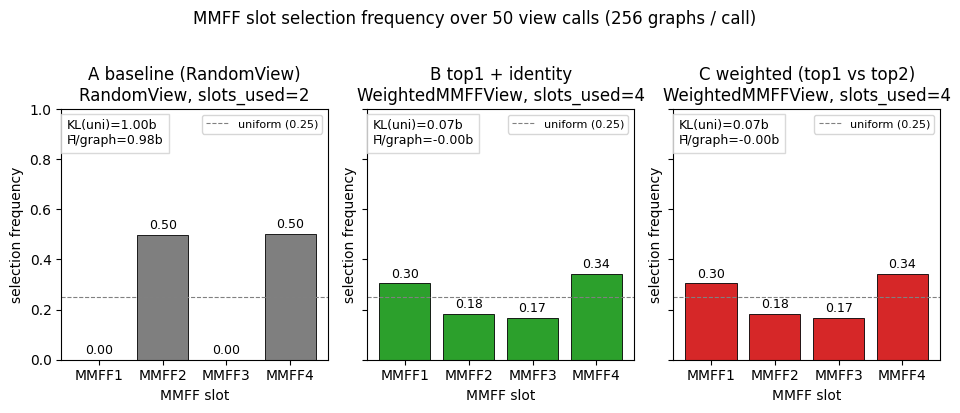

In [4]:
# --- 4. Slot distribution plot ---------------------------------------------
_n = len(SIDES)
fig, axes = plt.subplots(1, _n, figsize=(3.2 * _n, 4.0), sharey=True)
if _n == 1:
    axes = [axes]
for ax, side in zip(axes, SIDES):
    r = dist_results[side]
    bars = ax.bar(['MMFF1', 'MMFF2', 'MMFF3', 'MMFF4'], r['slot_freq'],
                  color=colors[side], edgecolor='black', linewidth=0.6)
    ax.axhline(0.25, color='gray', linestyle='--', linewidth=0.8,
               label='uniform (0.25)')
    ax.set_ylim(0, 1.0)
    ax.set_title(f"{labels[side]}\n{r['view_class']}, slots_used={r['n_slots_used']}")
    ax.set_xlabel('MMFF slot')
    ax.set_ylabel('selection frequency')
    ax.bar_label(bars, fmt='%.2f', padding=2, fontsize=9)
    ax.text(0.02, 0.96,
            f"KL(uni)={r['kl_to_uniform_bits']:.2f}b\nH̄/graph={r['per_graph_entropy_bits_mean']:.2f}b",
            transform=ax.transAxes, ha='left', va='top', fontsize=9,
            bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray'))
    ax.legend(loc='upper right', fontsize=8)

plt.suptitle(
    f'MMFF slot selection frequency over {DIST_N_CALLS} view calls '
    f'({DIST_BATCH} graphs / call)', y=1.02, fontsize=12)
plt.tight_layout()
out = RUN_DIR / f'slot_distribution_{FIG_TS}.png'
fig.savefig(out, dpi=140, bbox_inches='tight')
print('saved:', out)
plt.show()

## 3. 전체 Pretrain (A / B / C)

동일한 시드/하이퍼파라미터로 GraphCL 프리트레인을 **세** 번 돌립니다 (각 측면은 별도 폴더). 각 epoch loss 를 캡처해 곡선으로 그립니다.

In [5]:
# --- 5. Run full pretrain for each side -------------------------------------
pre_results = {}
for side in SIDES:
    root = MODEL_ROOT / side
    root.mkdir(parents=True, exist_ok=True)
    kw = dict(
        dataset=DATASET, batch_size=BATCH_SIZE,
        p_epoch=P_EPOCH, model_root=root, device=DEVICE,
        weight_kT=WEIGHT_KT, weight_mode=WEIGHT_MODE,
        weight_norm=WEIGHT_NORM,
        p_pretrain_amp=PRETRAIN_AMP,
        encoder=PRETRAIN_ENCODER,
        cutoff=PRETRAIN_CUTOFF,
        side_c_aug_2=SIDE_C_AUG_2,
    )
    if side in ('B', 'C'):
        kw['weights_path'] = WEIGHTS_PT
    print(f'\n===== pretrain side {side} =====')
    res = q.run_pretrain_side(side, **kw)
    pre_results[side] = res
    print(f"  view={res['view_classes']} wall={res['wall_s']:.1f}s")
    print(f"  best_ckpt={res['best_ckpt']}")
    if res['losses_per_epoch']:
        print(f"  losses: first={res['losses_per_epoch'][0]:.3f}  last={res['losses_per_epoch'][-1]:.3f}")
    gc.collect()
    if hasattr(torch, 'xpu'):
        try: torch.xpu.empty_cache()
        except Exception: pass

with open(RUN_DIR / 'pretrain_summary.json', 'w', encoding='utf-8') as f:
    json.dump(pre_results, f, indent=2, default=str)
print('\nsaved:', RUN_DIR / 'pretrain_summary.json')


===== pretrain side A =====


Pretraining: epoch 1:   0%|          | 0/25 [00:00<?, ?it/s]

c:\DGCL\3DGCL\models\quality_0513_1425\A/encoder-spherenet_pretrain-esol_batch-400_proj-spherenet_cutoff-3.0_layers-2_filter-128_gau-50_z_dim-32_lr-0.001_aug_1-MMFFrandom_aug_2-MMFFrandom_aug_ratio-0.25_tau-0.2_optim-ExponentialLR_weight_decay-0_expo_gamma-0.95_dropout-0.0


c:\DGCL\3DGCL\dig\sslgraph\utils\spherenet\features.py:320: UserWarning: Using torch.cross without specifying the dim arg is deprecated.
Please either pass the dim explicitly or simply use torch.linalg.cross.
The default value of dim will change to agree with that of linalg.cross in a future release. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\Cross.cpp:67.)
  b = torch.cross(pos_ji, pos_jk).norm(dim=-1) # sin_angle * |pos_ji| * |pos_jk|
Pretraining: epoch 25: 100%|██████████| 25/25 [05:48<00:00, 13.94s/it, loss=10.1029]


  view=['RandomView', 'RandomView'] wall=350.6s
  best_ckpt=C:\DGCL\3DGCL\models\quality_0513_1425\A\encoder-spherenet_pretrain-esol_batch-400_proj-spherenet_cutoff-3.0_layers-2_filter-128_gau-50_z_dim-32_lr-0.001_aug_1-MMFFrandom_aug_2-MMFFrandom_aug_ratio-0.25_tau-0.2_optim-ExponentialLR_weight_decay-0_expo_gamma-0.95_dropout-0.0\enc_best_epoch-14_loss-9.365.pkl
  losses: first=16.931  last=10.103

===== pretrain side B =====


...

  view=['WeightedMMFFView', 'function'] wall=256.8s
  best_ckpt=C:\DGCL\3DGCL\models\quality_0513_1425\B\encoder-spherenet_pretrain-esol_batch-400_proj-spherenet_cutoff-3.0_layers-2_filter-128_gau-50_z_dim-32_lr-0.001_aug_1-MMFFweighted_top1_aug_2-None_aug_ratio-0.25_tau-0.2_optim-ExponentialLR_weight_decay-0_expo_gamma-0.95_dropout-0.0\enc_best_epoch-25_loss-8.964.pkl
  losses: first=16.930  last=8.964

===== pretrain side C =====


Pretraining: epoch 1:   0%|          | 0/25 [00:00<?, ?it/s]

c:\DGCL\3DGCL\models\quality_0513_1425\C/encoder-spherenet_pretrain-esol_batch-400_proj-spherenet_cutoff-3.0_layers-2_filter-128_gau-50_z_dim-32_lr-0.001_aug_1-MMFFweighted_top1_aug_2-MMFFweighted_top2_aug_ratio-0.25_tau-0.2_optim-ExponentialLR_weight_decay-0_expo_gamma-0.95_dropout-0.0


Pretraining: epoch 25: 100%|██████████| 25/25 [04:05<00:00,  9.81s/it, loss=9.2892] 


  view=['WeightedMMFFView', 'WeightedMMFFView'] wall=246.3s
  best_ckpt=C:\DGCL\3DGCL\models\quality_0513_1425\C\encoder-spherenet_pretrain-esol_batch-400_proj-spherenet_cutoff-3.0_layers-2_filter-128_gau-50_z_dim-32_lr-0.001_aug_1-MMFFweighted_top1_aug_2-MMFFweighted_top2_aug_ratio-0.25_tau-0.2_optim-ExponentialLR_weight_decay-0_expo_gamma-0.95_dropout-0.0\enc_best_epoch-25_loss-9.289.pkl
  losses: first=16.930  last=9.289

saved: c:\DGCL\3DGCL\examples\sslgraph\bench\figs\pretrain_quality_0513_1425\pretrain_summary.json


saved: c:\DGCL\3DGCL\examples\sslgraph\bench\figs\pretrain_quality_0513_1425\pretrain_loss_0513_1425.png


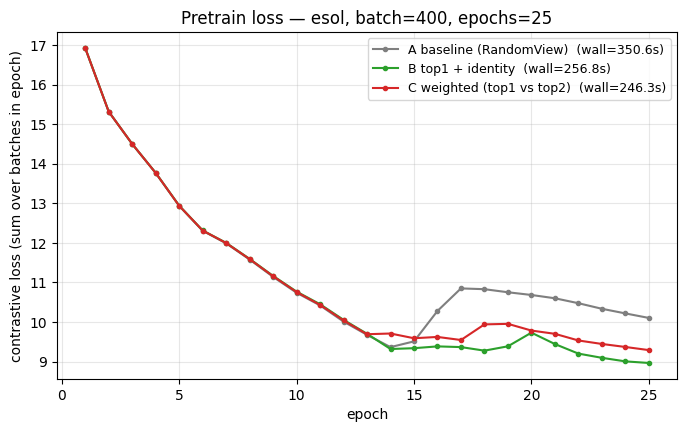

In [6]:
# --- 6. Loss curves ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4.5))
for side in SIDES:
    r = pre_results.get(side)
    if not r or not r['losses_per_epoch']:
        continue
    ys = r['losses_per_epoch']
    ax.plot(range(1, len(ys) + 1), ys, marker='o', markersize=3,
            color=colors[side], label=f"{labels[side]}  (wall={r['wall_s']:.1f}s)")
ax.set_xlabel('epoch')
ax.set_ylabel('contrastive loss (sum over batches in epoch)')
ax.set_title(f'Pretrain loss — {DATASET}, batch={BATCH_SIZE}, epochs={P_EPOCH}')
ax.grid(alpha=0.3)
ax.legend(loc='best', fontsize=9)
out = RUN_DIR / f'pretrain_loss_{FIG_TS}.png'
fig.savefig(out, dpi=140, bbox_inches='tight')
print('saved:', out)
plt.show()

## 3.5 분자별 MMFF 슬롯 가중치 보기

`WEIGHTS_PT` (예: `dataset/esol_mmff_weights_qdf.pt`) 를 사람이 읽을 수 있는 CSV 로 풀고, 가장 한쪽으로 \"치우친\" (uniform 에서 가장 먼) 분자 상위 10개와 가장 균등한 10개를 표로 보여줍니다.

CLI 로도 가능합니다 (`examples/sslgraph/bench/dump_mmff_weights.py`)::

```bash
python examples/sslgraph/bench/dump_mmff_weights.py \
    --in dataset/esol_mmff_weights_qdf.pt \
    --out dataset/esol_mmff_weights_qdf.csv \
    --sort-by top_minus_uniform
```

In [7]:
# --- 6.5 Per-molecule MMFF slot weight table ------------------------------
import pandas as pd
from IPython.display import display

csv_path = WEIGHTS_PT.with_suffix('.csv')
if not csv_path.is_file() and WEIGHTS_PT.is_file():
    _run([PY, 'examples/sslgraph/bench/dump_mmff_weights.py',
          '--in', WEIGHTS_PT, '--out', csv_path,
          '--sort-by', 'top_minus_uniform'])

if csv_path.is_file():
    df_w = pd.read_csv(csv_path)
    print(f'{csv_path}  ({len(df_w)} 분자)')
    # uniform 으로부터 가장 멀리 떨어진 (= 한 슬롯에 가장 표가 몰리는) 상위 10개
    print('\n[top-skewed] uniform 에서 멀리 떨어진 분자 상위 10개')
    display(df_w.head(10)[['smiles', 'w1', 'w2', 'w3', 'w4', 'top_slot', 'top_minus_uniform', 'entropy_bits']])
    # 가장 균등한 (entropy 가 log2(4)=2 에 가까운) 분자 10개
    print('\n[most-uniform] 가중치가 가장 평평한 분자 10개')
    display(df_w.nlargest(10, 'entropy_bits')[['smiles', 'w1', 'w2', 'w3', 'w4', 'top_slot', 'top_minus_uniform', 'entropy_bits']])
    print('\n전체 분포 요약')
    display(df_w[['w1', 'w2', 'w3', 'w4', 'entropy_bits', 'top_minus_uniform']].describe().T)
else:
    print(f'(skip) {WEIGHTS_PT} 또는 {csv_path} 가 없어 표시할 가중치가 없습니다.')

c:\DGCL\3DGCL\dataset\esol_mmff_weights_qdf_atomization.csv  (731 분자)

[top-skewed] uniform 에서 멀리 떨어진 분자 상위 10개


,smiles,w1,w2,w3,w4,top_slot,top_minus_uniform,entropy_bits
0,CCC(O)(CC)CC,0.075290,0.770233,0.079756,0.074721,2,0.520233,1.141634
1,CCCOCC,0.078256,0.069407,0.083280,0.769058,4,0.519058,1.144751
2,CCOCC,0.078720,0.768847,0.083596,0.068837,2,0.518847,1.145312
3,CCCCCC(=O)C,0.069895,0.075728,0.768744,0.085633,3,0.518744,1.145550
4,OC(Cn1cncn1)(c2ccc(F)cc2)c3ccccc3F,0.768308,0.078970,0.067790,0.084931,1,0.518308,1.146739
5,CC1CC2C3CCC4=CC(=O)C=CC4(C)C3(F)C(O)CC2(C)C1(O...,0.091348,0.069418,0.072376,0.766857,4,0.516857,1.150406
6,CCCCCC(C)C,0.084103,0.084516,0.064694,0.766687,4,0.516687,1.151079
7,CCCCCCCC,0.094004,0.071795,0.068542,0.765660,4,0.515660,1.153472
8,CCCOC(=O)c1ccc(N)cc1,0.765479,0.078637,0.064486,0.091398,1,0.515479,1.154145
9,CN(C=Nc1ccc(C)cc1C)C=Nc2ccc(C)cc2C,0.093121,0.065695,0.075766,0.765419,4,0.515419,1.154199



[most-uniform] 가중치가 가장 평평한 분자 10개


,smiles,w1,w2,w3,w4,top_slot,top_minus_uniform,entropy_bits
730,Cc1ccc(O)cc1C,0.309753,0.032069,0.343463,0.314715,3,0.093463,1.737332
729,CCOC=C,0.326893,0.297445,0.343575,0.032087,3,0.093575,1.736401
726,O=N(=O)c1cc(cc(c1)N(=O)=O)N(=O)=O,0.307854,0.294006,0.365995,0.032145,3,0.115995,1.732639
725,CCC(O)CC,0.032193,0.278998,0.320647,0.368162,4,0.118162,1.730308
727,O=C1NC(=O)C(=O)N1,0.270200,0.364699,0.332869,0.032232,2,0.114699,1.728803
720,CC34CCC1C(CC=C2CC(O)CCC12C)C3CCC4=O,0.032249,0.278442,0.305585,0.383724,4,0.133724,1.726293
728,CC(=O)N,0.255311,0.032346,0.361320,0.351023,3,0.111320,1.723827
714,CCCOC(=O)CCC,0.032281,0.392157,0.284629,0.290933,2,0.142157,1.723712
710,Cn1ccc(=O)[nH]c1=O,0.276518,0.394710,0.032309,0.296463,2,0.144710,1.722187
708,CC(C)CCOC=O,0.398336,0.274639,0.032334,0.294690,1,0.148336,1.720541



전체 분포 요약


,count,mean,std,min,25%,50%,75%,max
w1,731.0,0.222465,0.215659,0.032193,0.055133,0.119891,0.329390,0.768308
w2,731.0,0.239580,0.216758,0.032069,0.066212,0.143977,0.377327,0.770233
w3,731.0,0.251521,0.216604,0.032309,0.066876,0.165479,0.411474,0.768744
w4,731.0,0.286434,0.240857,0.032087,0.065056,0.203223,0.499717,0.769058
entropy_bits,731.0,1.451184,0.157126,1.141634,1.322453,1.479276,1.566563,1.737332
top_minus_uniform,731.0,0.342042,0.110685,0.093463,0.249084,0.342408,0.441252,0.520233


## 4. Finetune RMSE 비교 (downstream 정확도)

각 측면의 best 체크포인트를 SchNet 인코더에 로드해 ESOL 회귀로 finetune (3-fold scaffold split). 평균 test RMSE ± SD 를 보고합니다.

In [8]:
# --- 7. Finetune each checkpoint -------------------------------------------
# 주의: side 1개당 ESOL(1128분자) × 3-fold × F_EPOCH=30 ≈ 3~4분 (XPU Arc 140V 기준).
# SIDES 개수만큼 곱하면 됩니다. 빠르게 보고 싶으면 cell 1 의 F_EPOCH / QUALITY_SMOKE 를 조정한 뒤
# 이 셀만 재실행하면 됩니다.
# 부분 결과는 **side 가 끝날 때마다 즉시** ``finetune_summary.json`` 으로 저장됩니다.
# 따라서 도중에 Ctrl+C 를 눌러도 직전까지 끝난 측면의 RMSE 는 사라지지 않습니다.
# FINETUNE_BATCH 는 cell 1 의 노브를 사용 (기본 128, finetune.ipynb 기본 32 대비 ~2-3×).

# dig/sslgraph/evaluation/finetune.py 의 k_scaffold 가 ESOL 처럼 작은 데이터셋에서
# 더 견고하게 split 을 잡도록 수정됨 (seed perturbation 폭 확장). 셀만 재실행해도
# 새 코드가 반영되도록 명시적으로 reload — kernel restart 불필요.
import importlib
import dig.sslgraph.evaluation.finetune as _ft_mod
importlib.reload(_ft_mod)
import dig.sslgraph.evaluation as _ev_mod
importlib.reload(_ev_mod)
importlib.reload(q)  # pretrain_quality_core 도 새 Finetune 을 참조하도록

summary_path = RUN_DIR / 'finetune_summary.json'
if summary_path.is_file():
    try:
        fine_results = json.loads(summary_path.read_text(encoding='utf-8'))
        print(f'[resume] {summary_path} 에서 {sorted(fine_results.keys())} 측면 결과 발견 — 건너뜁니다.')
    except Exception:
        fine_results = {}
else:
    fine_results = {}

est_per_side_s = max(F_EPOCH, 1) * N_FOLDS * N_TIMES * 2.6  # 대략 XPU 기준
_n_sides = len(SIDES)
print(f'[plan] f_epoch={F_EPOCH} × n_folds={N_FOLDS} × n_times={N_TIMES} '
      f'~ side 1개당 ≈ {est_per_side_s:.0f}s ({est_per_side_s/60:.1f}분), '
      f'{_n_sides} sides ≈ {est_per_side_s*_n_sides/60:.1f}분')

try:
    for side in SIDES:
        if side in fine_results and fine_results[side].get('rmse_mean') is not None:
            r = fine_results[side]
            print(f'\n===== finetune side {side} (cached) =====')
            print(f"  RMSE = {r['rmse_mean']:.4f} ± {r['rmse_sd']:.4f}")
            continue
        _ts = time.strftime("%H:%M:%S")
        print(f'\n===== finetune side {side} (start at {_ts}) =====')
        t_side = time.perf_counter()
        r = q.run_finetune_side(
            pre_results[side],
            dataset=DATASET, batch_size=FINETUNE_BATCH,
            f_epoch=F_EPOCH, n_times=N_TIMES, n_folds=N_FOLDS,
            device=DEVICE,
        )
        fine_results[side] = r
        if r.get('rmse_mean') is not None:
            print(f"  RMSE = {r['rmse_mean']:.4f} ± {r['rmse_sd']:.4f}  "
                  f"(wall={r['wall_s']:.1f}s, elapsed={time.perf_counter()-t_side:.1f}s)")
        else:
            print('  finetune skipped/failed:', r.get('error'))
        # 즉시 저장 — Ctrl+C 안전
        with open(summary_path, 'w', encoding='utf-8') as f:
            json.dump(fine_results, f, indent=2, default=str)
        print(f'  [saved] {summary_path}')
        gc.collect()
        if hasattr(torch, 'xpu'):
            try: torch.xpu.empty_cache()
            except Exception: pass
except KeyboardInterrupt:
    print('\n[interrupted] 도중에 중단됨. 직전까지 끝난 측면의 결과는 보존됩니다:',
          {k: (v.get('rmse_mean'), v.get('rmse_sd')) for k, v in fine_results.items()})
    print(f'재개하려면 이 셀을 다시 실행 — {summary_path} 의 캐시를 자동으로 사용합니다.')

print('\nsaved:', summary_path, '   sides done:', sorted(fine_results.keys()))

[plan] f_epoch=25 × n_folds=1 × n_times=1 ~ side 1개당 ≈ 65s (1.1분), 3 sides ≈ 3.2분

===== finetune side A (start at 14:41:14) =====


c:\DGCL\3DGCL\dig\sslgraph\evaluation\finetune.py:290: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. The given 'InMemoryDataset' only references a subset of examples of the full dataset, but 'data' will contain information of the full dataset. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  self.dataset.data.y = self.dataset.data[self.target]


[k_scaffold] preparing fold 1/1 (scaffold split over 1128 molecules)...
895 112 121


Finetune: epoch 25: 100%|██████████| 25/25 [02:30<00:00,  6.00s/it, FOLD=1.0, best_test_loss=1.116, best_val_loss=1.026, test_rmse=1.116, train_rmse=nan, val_rmse=1.026]


  RMSE = 1.1157 ± 0.0000  (wall=157.0s, elapsed=157.5s)
  [saved] c:\DGCL\3DGCL\examples\sslgraph\bench\figs\pretrain_quality_0513_1425\finetune_summary.json

===== finetune side B (start at 14:43:51) =====


...

  RMSE = 1.1226 ± 0.0000  (wall=139.8s, elapsed=140.1s)
  [saved] c:\DGCL\3DGCL\examples\sslgraph\bench\figs\pretrain_quality_0513_1425\finetune_summary.json

===== finetune side C (start at 14:46:12) =====


c:\DGCL\3DGCL\dig\sslgraph\evaluation\finetune.py:290: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. The given 'InMemoryDataset' only references a subset of examples of the full dataset, but 'data' will contain information of the full dataset. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  self.dataset.data.y = self.dataset.data[self.target]


[k_scaffold] preparing fold 1/1 (scaffold split over 1128 molecules)...
895 112 121


Finetune: epoch 25: 100%|██████████| 25/25 [03:46<00:00,  9.05s/it, FOLD=1.0, best_test_loss=1.056, best_val_loss=0.956, test_rmse=1.056, train_rmse=nan, val_rmse=0.956]


  RMSE = 1.0559 ± 0.0000  (wall=231.1s, elapsed=231.9s)
  [saved] c:\DGCL\3DGCL\examples\sslgraph\bench\figs\pretrain_quality_0513_1425\finetune_summary.json

saved: c:\DGCL\3DGCL\examples\sslgraph\bench\figs\pretrain_quality_0513_1425\finetune_summary.json    sides done: ['A', 'B', 'C']


saved: c:\DGCL\3DGCL\examples\sslgraph\bench\figs\pretrain_quality_0513_1425\finetune_rmse_0513_1425.png


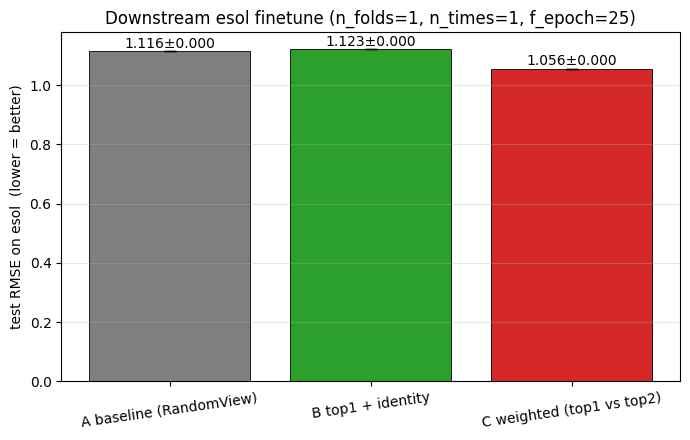

In [9]:
# --- 8. RMSE bar chart -----------------------------------------------------
fig, ax = plt.subplots(figsize=(7.0, 4.5))
xs, ys, errs, txts, bar_colors = [], [], [], [], []
for side in SIDES:
    r = fine_results.get(side, {})
    m = r.get('rmse_mean')
    if m is None or np.isnan(m):
        continue
    xs.append(labels[side])
    ys.append(m)
    errs.append(r.get('rmse_sd') or 0.0)
    txts.append(f"{m:.3f}±{r.get('rmse_sd', 0.0):.3f}")
    bar_colors.append(colors[side])
bars = ax.bar(xs, ys, yerr=errs, capsize=4,
              color=bar_colors,
              edgecolor='black', linewidth=0.6)
ax.set_ylabel(f'test RMSE on {DATASET}  (lower = better)')
ax.set_title(f'Downstream {DATASET} finetune (n_folds={N_FOLDS}, n_times={N_TIMES}, f_epoch={F_EPOCH})')
ax.grid(axis='y', alpha=0.3)
for bar, txt in zip(bars, txts):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(errs or [0]) * 1.05 + 1e-3,
            txt, ha='center', va='bottom', fontsize=10)
for lbl in ax.get_xticklabels():
    lbl.set_rotation(8)
out = RUN_DIR / f'finetune_rmse_{FIG_TS}.png'
plt.tight_layout()
fig.savefig(out, dpi=140, bbox_inches='tight')
print('saved:', out)
plt.show()

In [10]:
# --- 9. Combined summary table ---------------------------------------------
import pandas as pd
rows = []
for side in SIDES:
    pr = pre_results.get(side, {})
    fr = fine_results.get(side, {})
    dr = dist_results.get(side, {})
    rows.append({
        'side': side,
        'label': labels[side],
        'view': ','.join(pr.get('view_classes', [])),
        'pretrain_wall_s': pr.get('wall_s'),
        'pretrain_last_loss': (pr.get('losses_per_epoch') or [None])[-1],
        'rmse_mean': fr.get('rmse_mean'),
        'rmse_sd': fr.get('rmse_sd'),
        'finetune_wall_s': fr.get('wall_s'),
        'slots_used': dr.get('n_slots_used'),
        'kl_to_uniform_bits': dr.get('kl_to_uniform_bits'),
        'per_graph_entropy_bits_mean': dr.get('per_graph_entropy_bits_mean'),
    })
df = pd.DataFrame(rows)
df.to_csv(RUN_DIR / 'summary.csv', index=False)
print('saved:', RUN_DIR / 'summary.csv')
df

saved: c:\DGCL\3DGCL\examples\sslgraph\bench\figs\pretrain_quality_0513_1425\summary.csv


,side,label,view,pretrain_wall_s,pretrain_last_loss,rmse_mean,rmse_sd,finetune_wall_s,slots_used,kl_to_uniform_bits,per_graph_entropy_bits_mean
0,A,A baseline (RandomView),"RandomView,RandomView",350.647271,10.102876,1.115660,0.0,157.038779,2,1.000003,9.847383e-01
1,B,B top1 + identity,"WeightedMMFFView,function",256.787039,8.963774,1.122599,0.0,139.787308,4,0.066744,-1.442823e-12
2,C,C weighted (top1 vs top2),"WeightedMMFFView,WeightedMMFFView",246.299198,9.289240,1.055875,0.0,231.149904,4,0.066744,-1.442823e-12


## 노트

1. **스모크 vs 본격**
   - 셀 1 에서 `QUALITY_SMOKE = True` 를 켜면 짧은 epoch/fold·SchNet·적은 `DIST_N_CALLS` 로 빠르게 통과 확인.
   - 수동 스모크: `P_EPOCH=2~5`, `F_EPOCH=10~20` 등. 본격 비교: `QUALITY_SMOKE = False` 후 `P_EPOCH=50~100`, `F_EPOCH=100`, `N_TIMES=3`.
2. **재현성**
   - 모든 셀이 `seed=2222` 사용. `MMFFRANDOM_FAST` / `MMFFRANDOM_WEIGHTED` 환경변수는 `pretrain_quality_core` 내부의 `_clean_aug_env()` 가 자동으로 마스킹.
   - 호스트 환경 변수는 셀 종료 후 원상복귀 (non-destructive).
3. **체크포인트**
   - `./models/quality_<MMDD_HHMM>/{A,B,C}/...` 에 각각 별도 저장. 같은 시간대에 여러 번 돌리면 폴더 이름의 분 단위 timestamp 가 달라지면서 자동 분리.
4. **`C` 가 `A` 보다 RMSE 가 낮지 않다면**
   - `WEIGHT_KT` 를 0.1~0.5 로 줄여 분포를 더 첨예하게.
   - `QDF_PROPERTY` 를 `atomization` 으로 (homolumo 는 conformer 간 spread 가 매우 작음).
   - `compute_mmff_weights.py` 메타데이터 (`meta['qdf_property']`, `meta['normalize']`) 가 의도대로인지 확인.
   - epoch 을 늘려서 학습 신호를 더 받게.

5. **Finetune 시간**
   - side 개수는 `SIDES` (기본 A/B/C 세 개). 시간은 대략 side 1개당 비용 × `len(SIDES)`.
   - 더 빠르게: `QUALITY_SMOKE`, 또는 `N_FOLDS=2` + `F_EPOCH=20`.
   - 더 정확하게 (느려짐): `N_TIMES=3` × `N_FOLDS=5` × `F_EPOCH=100`.
   - `FINETUNE_BATCH` 를 256/512 로 더 키워도 됨 (z_dim=32, SchNet 가벼움); ESOL 1128 분자라 batch=512 면 train_loader 가 fold 당 2 batch.

6. **B 측면**
   - **B (현재)**: `MMFFweighted_top1` + `aug_2=None` → 첫 뷰만 가중 argmax 슬롯, 둘째 뷰는 원본 좌표(identity). 예전 *fast random* B 와는 다른 ablation.
   - 속도/커널만 보려면 `compare_pretrain_ab.py` 를 사용.